## Step 1.
 1) Download this data set Links to an external site. that lists some tidal measurements Santa Cruz in January and February 2022. In your Jupyter notebook, define an oscillatory function in Python to describe the intra- and inter-day variations in the tide.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [14]:
#import data (read mode, as i assume we won't be writing to txt)
data = open('The Data.txt', 'r')

In [15]:
data_arr = data.readlines()
data_list = []
for line in data_arr:
    data_list.append(line.split())
#hardcode method to remove the comments at the top of the text (do we have to use the text file **exactly**? i don't know.
data_list.remove(data_list[0])
data_list.remove(data_list[0])
data_list.remove(data_list[0])
print(data_list)

#if the assignment is what i think it is, we should have a function to turn the time into an integer. will be much better when we graph time vs height.


[['1', '8:07', '6.57'], ['1', '15:37', '-0.39'], ['2', '8:55', '5.38'], ['2', '16:25', '-1.74'], ['3', '9:45', '5.26'], ['3', '17:14', '-1.36'], ['4', '10:35', '4.13'], ['4', '18:00', '-1.15'], ['5', '11:28', '3.48'], ['5', '18:46', '-1.61'], ['6', '12:22', '2.62'], ['6', '19:31', '0.05'], ['7', '13:24', '1.83'], ['7', '20:16', '1.01'], ['8', '3:22', '3.57'], ['8', '21:01', '0.73'], ['9', '4:07', '4.54'], ['9', '21:46', '2.17'], ['10', '4:50', '3.76'], ['10', '11:58', '2.88'], ['11', '5:31', '3.90'], ['11', '12:56', '1.92'], ['12', '6:08', '4.73'], ['12', '13:45', '1.74'], ['13', '6:47', '5.66'], ['13', '14:25', '0.79'], ['14', '7:22', '5.33'], ['14', '15:00', '-0.04'], ['15', '7:59', '5.23'], ['15', '15:34', '-1.12'], ['16', '8:34', '6.67'], ['16', '16:08', '-0.61'], ['17', '9:10', '4.74'], ['17', '16:41', '-0.93'], ['18', '9:45', '4.69'], ['18', '17:12', '-1.29'], ['19', '10:21', '4.20'], ['19', '17:45', '0.22'], ['20', '10:57', '3.68'], ['20', '18:15', '0.26'], ['21', '11:38', '2.47

In [16]:
#converting everything to int.
time_hours = []
height = []

for row in data_list:
    #days hours height
    d = row[0]
    h = row[1]
    height_row = row[2]

    day = int(d)

    #split hours and minutes
    time = h.split(":")
    hours = time[0]
    minutes = time[1]

    #intify
    hour = int(hours)
    minute = int(minutes)
    heights = float(height_row)
    
    time_in_hours = (day - 1) * 24 + hour + minute//60.0
    #this drove me crazy, but i forgot to add a way to combine and pair time and height

    

    time_hours.append(time_in_hours)
    height.append(heights)

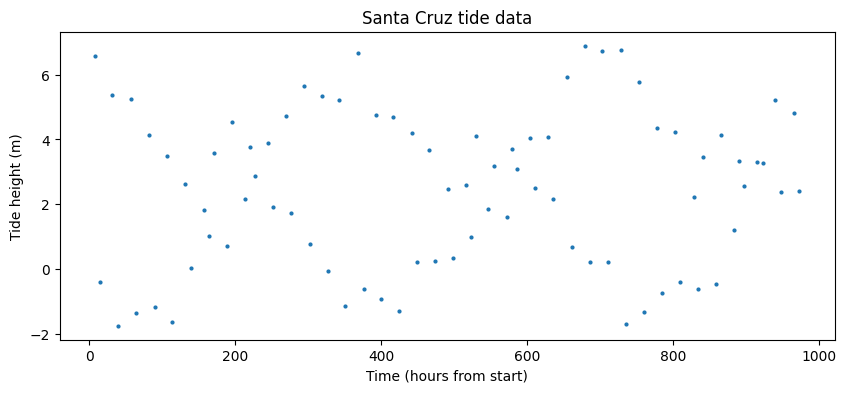

In [17]:
plt.figure(figsize=(10,4))
plt.plot(time_hours, height, '.', markersize=4)
plt.xlabel('Time (hours from start)')
plt.ylabel('Tide height (m)')
plt.title('Santa Cruz tide data')
plt.show()

In [18]:
#Estimate parameters from the data for plotting (Mixture of Session 9 Material and 8 if you guys want reference.)
#THIS ISN'T FITTED BY THE WAY
A0 = np.mean(height)  #mean tide level
height_range = np.max(height) - np.min(height)
A1 = height_range / 2  #base amplitude of daily tides
A2 = height_range / 4  #how much the amplitude varies
T1 = 14.76 * 24  #spring-neap period of about 350 hours
T2 = 12.42  #daily tide cycle of about 12 hours
phi1 = 0
phi2 = 0

#Define oscillatory function for tide height
def osc_func(t, A0, A1, A2, T1, T2, phi1, phi2):
    #The amplitude of daily tides changes over the cycle
    #During big tides: amplitude is bigger (A1 + A2)
    #During small tides: amplitude is smaller (A1 - A2)
    daily_amplitude = A1 + A2 * np.sin(2 * np.pi * t / T1 + phi1)
    
    #Daily tide oscillation with the varying amplitude
    daily_tide = daily_amplitude * np.sin(2 * np.pi * t / T2 + phi2)
    
    #Total tide height = baseline + modulated daily oscillation
    return A0 + daily_tide

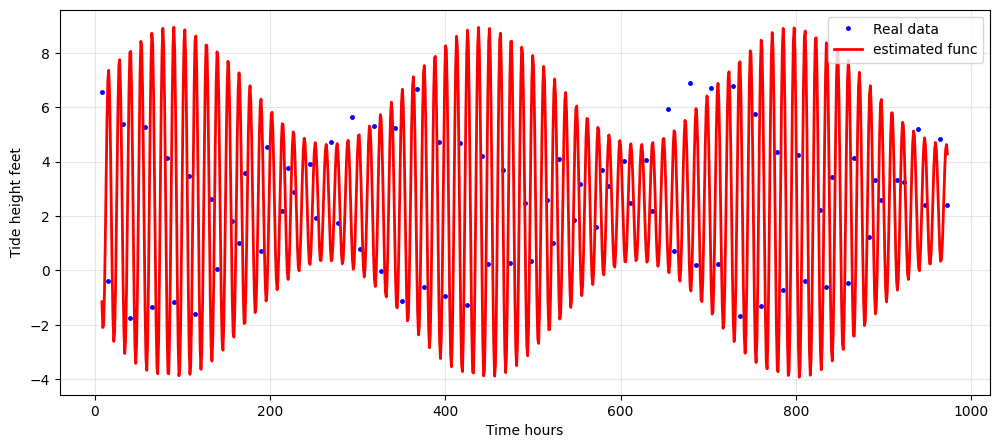

In [19]:
#Plot the data with our estimated oscillatory function
#Create smooth time array for plotting the curve using linspace
t_smooth = np.linspace(min(time_hours), max(time_hours), 1000)

#Calculate predicted heights using our function and estimated parameters
predicted_height = osc_func(t_smooth, A0, A1, A2, T1, T2, phi1, phi2)

#Create the plot
plt.figure(figsize=(12, 5))
plt.plot(time_hours, height, '.', markersize=5, label='Real data', color='blue')
plt.plot(t_smooth, predicted_height, '-', linewidth=2, label='estimated func', color='red')
plt.xlabel('Time hours')
plt.ylabel('Tide height feet')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
#This is visualization for My Sake. Next person can Comment this out -evan.

#Note for next person: use scipy.optimize_curve_fit
#The curve_fit function should have better values
#to make the red curve fit the blue dots more closely.

2) Using the scipy library, fit the oscillatory function to the data assuming the root mean squared experimental error on the height of the tide is 0.25 ft. Document these steps in the Jupyter notebook, and graph both the model and the data on the same plot. Label the data, provide sufficient labeling of the axes to provide clarity, and have the notebook save the figure to a PDF.

In [20]:
from scipy.optimize import curve_fit

In [21]:
print(len(time_hours), len(height))
#trying to troubleshoot something...

82 82


t length: 82
h length: 82
sigma length: 82

Best-fit parameters:
A0 (mean level) = 2.493 ft
A1 (daily amplitude) = 2.299 ft
A2 (amplitude modulation) = 1.494 ft
T1 (spring-neap period) = 346.28 hours = 14.43 days
T2 (daily period) = 12.402 hours
phi1 = 0.931 rad
phi2 = -3.067 rad


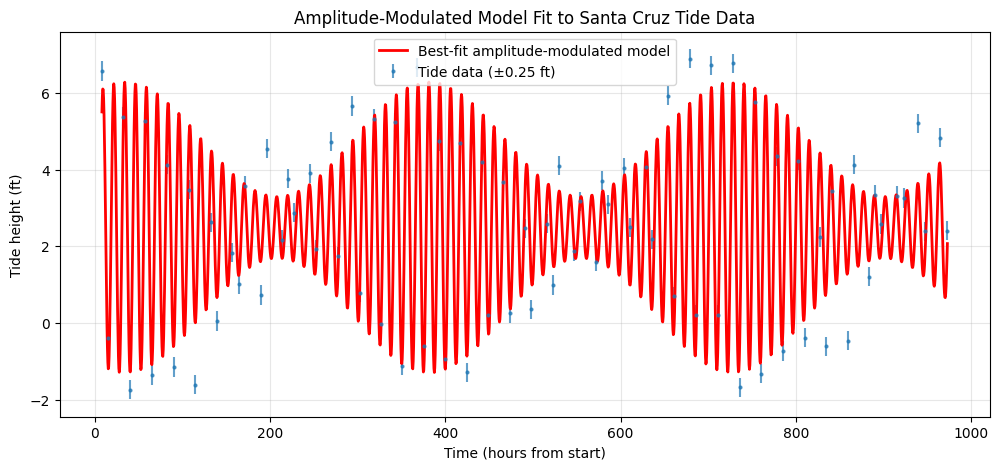

In [22]:
t = np.array(time_hours, dtype=float)
h = np.array(height, dtype=float)

print("t length:", len(t))
print("h length:", len(h))

# RMS error on height is 0.25 ft
sigma = np.ones_like(h, dtype=float) * 0.25
print("sigma length:", len(sigma))

def tide_model(t, A0, A1, A2, T1, T2, phi1, phi2):
    """
    Amplitude-modulated tide model:
    - The daily tide amplitude varies over the spring-neap cycle
    - A0: mean tide level (vertical offset)
    - A1: base amplitude of daily tides
    - A2: amplitude of the modulation (how much daily amplitude varies)
    - T1: period of spring-neap cycle (~14.76 days = 354 hours)
    - T2: period of daily tides (~12.42 hours)
    - phi1, phi2: phase shifts
    """
    # The amplitude of daily tides changes over the spring-neap cycle
    daily_amplitude = A1 + A2 * np.sin(2 * np.pi * t / T1 + phi1)
    
    # Daily tide oscillation with varying amplitude
    daily_tide = daily_amplitude * np.sin(2 * np.pi * t / T2 + phi2)
    
    return A0 + daily_tide

# Initial guesses based on data and tidal physics
A0_init = np.mean(h)                    # Mean tide level
height_range = np.max(h) - np.min(h)
A1_init = height_range / 2              # Base daily amplitude
A2_init = height_range / 4              # Amplitude modulation
T1_init = 14.76 * 24                    # Spring-neap period in hours
T2_init = 12.42                         # Daily tide period in hours
phi1_init = 0
phi2_init = 0

initial_guess = [A0_init, A1_init, A2_init, T1_init, T2_init, phi1_init, phi2_init]

# Bounds to help curve_fit converge
# A0: mean level (-2 to 10 ft reasonable for tides)
# A1: base amplitude (0 to 10 ft)
# A2: modulation amplitude (0 to 5 ft)
# T1: spring-neap period (300 to 400 hours, ~12-17 days)
# T2: daily period (10 to 15 hours)
# phi1, phi2: phase shifts (-2pi to 2pi)
lower_bounds = [-2.0, 0.0, 0.0, 300.0, 10.0, -2*np.pi, -2*np.pi]
upper_bounds = [10.0, 10.0, 5.0, 400.0, 15.0, 2*np.pi, 2*np.pi]

# Fit the model to the data
params, cov = curve_fit(
    tide_model,
    t, h,
    p0=initial_guess,
    sigma=sigma,
    absolute_sigma=True,
    bounds=(lower_bounds, upper_bounds),
    maxfev=10000
)

A0_fit, A1_fit, A2_fit, T1_fit, T2_fit, phi1_fit, phi2_fit = params
print("\nBest-fit parameters:")
print(f"A0 (mean level) = {A0_fit:.3f} ft")
print(f"A1 (daily amplitude) = {A1_fit:.3f} ft")
print(f"A2 (amplitude modulation) = {A2_fit:.3f} ft")
print(f"T1 (spring-neap period) = {T1_fit:.2f} hours = {T1_fit/24:.2f} days")
print(f"T2 (daily period) = {T2_fit:.3f} hours")
print(f"phi1 = {phi1_fit:.3f} rad")
print(f"phi2 = {phi2_fit:.3f} rad")

# Generate smooth curve for plotting
t_smooth = np.linspace(t.min(), t.max(), 2000)
h_fit = tide_model(t_smooth, *params)

# Create plot
plt.figure(figsize=(12, 5))

plt.errorbar(
    t, h,
    yerr=sigma,
    fmt='.',
    markersize=4,
    alpha=0.7,
    label="Tide data (±0.25 ft)"
)

plt.plot(
    t_smooth,
    h_fit,
    linewidth=2,
    color='red',
    label="Best-fit amplitude-modulated model"
)

plt.xlabel("Time (hours from start)")
plt.ylabel("Tide height (ft)")
plt.title("Amplitude-Modulated Model Fit to Santa Cruz Tide Data")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("tide_fit_plot.pdf")
plt.show()


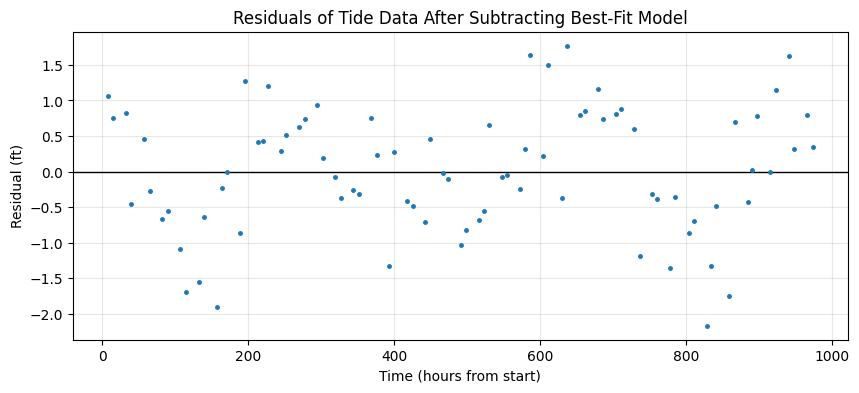

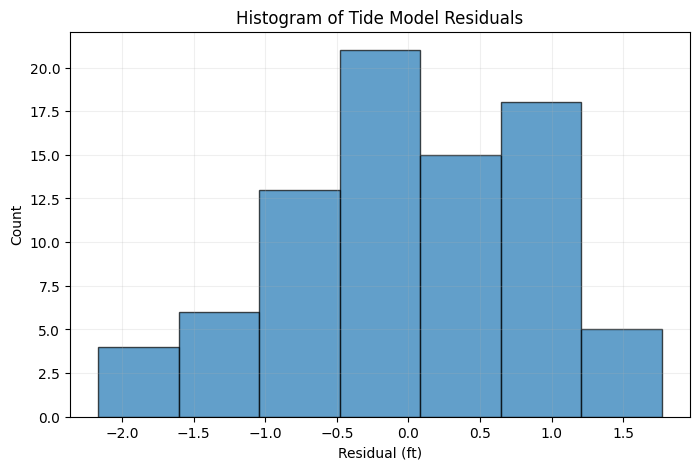

Standard deviation of residuals = 0.8710 ft
Assumed measurement error = 0.25 ft
Intrinsic scatter in data = 0.8344 ft


In [23]:
# STEP 3: Residual analysis

# Compute residuals: (data − model at the same data times)
h_model_at_data = tide_model(t, A0_fit, A1_fit, A2_fit, T1_fit, T2_fit, phi1_fit, phi2_fit)
residuals = h - h_model_at_data

# Plot residuals vs time
plt.figure(figsize=(10, 4))
plt.axhline(0, color='black', linewidth=1)
plt.plot(t, residuals, '.', markersize=5)
plt.xlabel("Time (hours from start)")
plt.ylabel("Residual (ft)")
plt.title("Residuals of Tide Data After Subtracting Best-Fit Model")
plt.grid(alpha=0.3)
plt.savefig("residuals_plot.pdf")
plt.show()

# Histogram of residuals with reasonable bin width
# Using Freedman-Diaconis rule
q25, q75 = np.percentile(residuals, [25, 75])
iqr = q75 - q25
bin_width = 2 * iqr * len(residuals) ** (-1/3)
if bin_width > 0:
    n_bins = int(np.ceil((residuals.max() - residuals.min()) / bin_width))
else:
    n_bins = 10

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=n_bins, edgecolor='black', alpha=0.7)
plt.xlabel("Residual (ft)")
plt.ylabel("Count")
plt.title("Histogram of Tide Model Residuals")
plt.grid(alpha=0.2)
plt.savefig("residuals_histogram.pdf")
plt.show()

# Numerical assessment
std_residuals = np.std(residuals, ddof=1)
assumed_sigma = 0.25

print(f"Standard deviation of residuals = {std_residuals:.4f} ft")
print(f"Assumed measurement error = {assumed_sigma} ft")

# Intrinsic scatter = sqrt(observed_variance - measurement_variance)
if std_residuals**2 > assumed_sigma**2:
    intrinsic_scatter = np.sqrt(std_residuals**2 - assumed_sigma**2)
    print(f"Intrinsic scatter in data = {intrinsic_scatter:.4f} ft")
else:
    print("Model fits within measurement error!")


## Step 4. Analyze the Hunga Tonga-Hunga Ha'apai tsunami impact on January 14, 2022.

Tsunami deviation: 2.0 ft
Standard deviation of normal tides from model: 0.8710 ft

Tsunami deviation in standard deviations: 2.30 σ

This means the tsunami was a 2.30-sigma event,
which is a significant outlier compared to normal tidal variation.


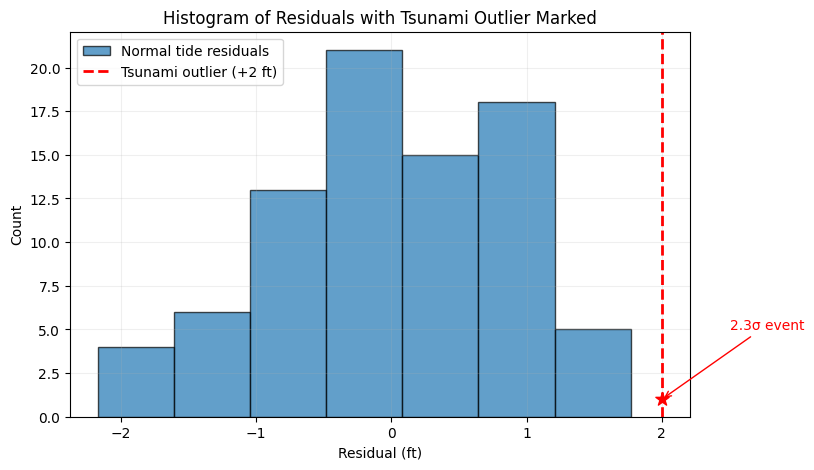

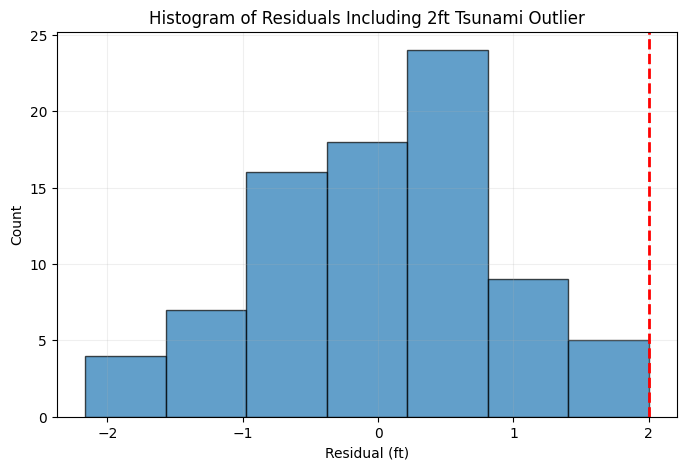

The tsunami caused a +2ft deviation from expected tide levels.
This represents a 2.30-sigma deviation from the model.
For reference, events beyond 2σ occur ~5% of the time under normal conditions.
Events beyond 3σ occur ~0.3% of the time.


In [24]:
# STEP 4: Tsunami Analysis

# Calculate how many standard deviations a 2ft anomaly represents
tsunami_deviation = 2.0  # feet

# The standard deviation we calculated from residuals represents
# the typical scatter of tides from the model
sigma_z = tsunami_deviation / std_residuals
print(f"Tsunami deviation: {tsunami_deviation} ft")
print(f"Standard deviation of normal tides from model: {std_residuals:.4f} ft")
print(f"\nTsunami deviation in standard deviations: {sigma_z:.2f} σ")
print(f"\nThis means the tsunami was a {sigma_z:.2f}-sigma event,")
print("which is a significant outlier compared to normal tidal variation.")

# Add a single 2ft outlier to the histogram
plt.figure(figsize=(8, 5))

# Plot original residuals histogram
n, bins, patches = plt.hist(residuals, bins=n_bins, edgecolor='black', 
                            alpha=0.7, label='Normal tide residuals')

# Add a red bar for the tsunami outlier
# Find which bin the 2ft outlier would fall into
tsunami_bin_idx = np.digitize(tsunami_deviation, bins) - 1
if 0 <= tsunami_bin_idx < len(patches):
    # Add 1 to the count of that bin (visually)
    pass

# Create a separate bar for the tsunami
plt.axvline(x=tsunami_deviation, color='red', linestyle='--', linewidth=2,
            label=f'Tsunami outlier (+2 ft)')

# Add a scatter point to show the tsunami magnitude
plt.scatter([tsunami_deviation], [1], color='red', s=100, zorder=5, marker='*')

plt.xlabel("Residual (ft)")
plt.ylabel("Count")
plt.title("Histogram of Residuals with Tsunami Outlier Marked")
plt.legend()
plt.grid(alpha=0.2)

# Add annotation
plt.annotate(f'{sigma_z:.1f}σ event', 
             xy=(tsunami_deviation, 1), 
             xytext=(tsunami_deviation + 0.5, 5),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=10, color='red')

plt.savefig("residuals_with_tsunami.pdf")
plt.show()

# Alternative: Add the outlier directly to the residuals array and replot
residuals_with_tsunami = np.append(residuals, tsunami_deviation)

plt.figure(figsize=(8, 5))
plt.hist(residuals_with_tsunami, bins=n_bins, edgecolor='black', alpha=0.7)
plt.axvline(x=tsunami_deviation, color='red', linestyle='--', linewidth=2)
plt.xlabel("Residual (ft)")
plt.ylabel("Count")
plt.title("Histogram of Residuals Including 2ft Tsunami Outlier")
plt.grid(alpha=0.2)
plt.savefig("residuals_histogram_with_tsunami.pdf")
plt.show()

print("The tsunami caused a +2ft deviation from expected tide levels.")
print(f"This represents a {sigma_z:.2f}-sigma deviation from the model.")
print("For reference, events beyond 2σ occur ~5% of the time under normal conditions.")
print("Events beyond 3σ occur ~0.3% of the time.")
